# Station-MAE — Per-station MAE / RMSE on the Swiss Map

Visualises per-station MAE / RMSE on the Swiss topographic map, for any run under
`test_results/<RUN_NAME>/best_mr*/predictions.pt` (v27-style dumps: `test.py` /
`test_masked_transformer.py` / `test_lstm.py` all write this schema — see
`notebooks/Test_Results_Exploration.ipynb` for the full model-comparison analysis).

Moved from `archive/plot_test_results.ipynb` and updated for the current test-dump
format:

- **No `per_station_metrics.csv`.** Earlier runs had a separate CSV with
  precomputed per-station metrics; v27+ dumps only contain raw tensors
  (`preds`, `targets`, `masks`, `masked_idx`, `spatial`, ...). This notebook computes
  the per-station MAE/RMSE table itself, directly from those tensors
  (`per_station_mae_table()` below) — same math as
  `engine/evaluate.py::evaluate_per_station()`, just run against a saved dump
  instead of a live model + loader.
- **Real `masked_idx`.** v27's mr0.50 dumps record exactly which stations were
  hidden from the encoder for each window, so §10 now reads that directly instead
  of re-simulating the random mask.
- **Station list / physical σ** come from `StationMAEDataset._resolve_keep_indices()`
  and `compute_obs_stats()` — the same helpers `notebooks/Test_Results_Exploration.ipynb`
  uses — so the station ordering and normalisation are guaranteed consistent with
  training, and a shape-mismatch guard catches any drift instead of silently
  mis-labelling stations.

For:
- **mr0.00** — all stations visible (pure temporal forecasting)
- **mr0.50** — 50% stations masked (gap-filling + forecasting), if the run has it

Also shows performance **grouped by 5 terrain / climate zones** and the model vs
persistence skill map.

---
### Terrain classification — assumptions

| Category | Altitude | Geographic filter | Climate character |
|---|---|---|---|
| Swiss Plateau / Lowland | < 600 m | LV95 northing >= 1 130 000 m | Temperate continental, Rhine/Rhone lowlands |
| Pre-Alpine / Jura | 600-1 400 m | LV95 northing >= 1 130 000 m | Humid, orographic precipitation, Jura ridges |
| Alpine | 1 400-2 200 m | LV95 northing >= 1 130 000 m | Mountain snow regime, sheltered valleys |
| High Alpine | > 2 200 m | any | Exposed summit regime, year-round snow |
| Southern Switzerland | < 2 000 m | LV95 northing < 1 130 000 m | Mediterranean-influenced, Ticino/Valais-Sud |

**Key assumption**: the main Alpine divide sits at approximately LV95 northing ~
1 130 000 m (EPSG:2056). Stations south of this with altitude < 2 000 m get
*Southern Switzerland* regardless of elevation; summit stations (> 2 200 m) stay
*High Alpine* regardless of north/south position. Adjust `ALPS_DIVIDE_NORTHING` if a
station near the watershed looks misclassified on the terrain map (Section 1).

**Minimum sample filter**: stations with fewer than `MIN_SAMPLES` valid sensor
observations for a given variable are excluded from grouped statistics but still
shown on maps.

(This 5-category split is finer than the mountain/valley binary split used in
`Test_Results_Exploration.ipynb` §3 — kept here because the terrain-grouped and
masking-penalty sections below were designed around it.)

In [7]:
# ── Config & project bootstrap ────────────────────────────────────────────────
import os, sys
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import geopandas as gpd
import rioxarray  # noqa - registers .rio accessor on xarray DataArrays

# This notebook lives in notebooks/ but reads checkpoints/, test_results/ and
# report/ from the project root, and imports data/engine/model from src/.
# Re-running this cell is safe (it only climbs out of notebooks/ once) - same
# bootstrap pattern as Test_Results_Exploration.ipynb.
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
PROJ = os.getcwd()
if os.path.join(PROJ, "src") not in sys.path:
    sys.path.insert(0, os.path.join(PROJ, "src"))

# ── Run to visualise ── test_results/<RUN_NAME>/best_mr*/predictions.pt
RUN_NAME = "v27"
EXCLUDE  = ["PFA"]

RESULTS_DIR = os.path.join(PROJ, "test_results", RUN_NAME)
REPORT_DIR  = os.path.join(PROJ, "report")

# swissBOUNDARIES3D shapefile (.shp.zip or unpacked .shp) - update for your machine
PATH_SWISSSHAPE = os.path.expanduser(
    "~/Documents/ETH/_DAS Project/swissboundaries3d_2026-01_2056_5728.shp.zip"
)

# Candidate PeakWeatherDataset roots - same search order as
# Test_Results_Exploration.ipynb, so both notebooks find the data without editing.
_CAND = ["/home/renku/work/PeakWeatherDataset",
         os.path.expanduser("~/Documents/ETH/_DAS Project/PeakWeatherDataset"),
         os.path.expanduser("~/PeakWeatherDataset"),
         os.path.join(PROJ, "PeakWeatherDataset")]
DATA_ROOT = next((p for p in _CAND if os.path.isdir(p)), _CAND[-1])

# ── Terrain classification parameters ──────────────────────────────────────
ALPS_DIVIDE_NORTHING = 1_130_000
MIN_SAMPLES = 50

# ── Variable metadata ───────────────────────────────────────────────────────
# (name, mae_column, physical unit, colormap, (vmin, vmax))
# plasma_r: yellow (low/good) -> magenta -> purple (high/bad)
VARIABLES = [
    ('temperature', 'temperature_mae', 'deg C', 'plasma_r', (0, 3.5)),
    ('pressure',    'pressure_mae',    'hPa',   'plasma_r', (0, 5.0)),
    ('humidity',    'humidity_mae',    '%',     'plasma_r', (0, 20.)),
    ('wind_u',      'wind_u_mae',      'm/s',   'plasma_r', (0, 3.0)),
    ('wind_v',      'wind_v_mae',      'm/s',   'plasma_r', (0, 3.0)),
]

TERRAIN_CATEGORIES = [
    'Swiss Plateau / Lowland',
    'Pre-Alpine / Jura',
    'Alpine',
    'High Alpine',
    'Southern Switzerland',
]
TERRAIN_COLORS = {
    'Swiss Plateau / Lowland': '#4CAF50',
    'Pre-Alpine / Jura':       '#2196F3',
    'Alpine':                  '#9C27B0',
    'High Alpine':             '#F44336',
    'Southern Switzerland':    '#FF9800',
}
TERRAIN_SHORT = {
    'Swiss Plateau / Lowland': 'Plateau',
    'Pre-Alpine / Jura':       'Pre-Alp',
    'Alpine':                  'Alpine',
    'High Alpine':             'High Alp',
    'Southern Switzerland':    'South CH',
}

print('PROJ        :', PROJ)
print('RUN_NAME    :', RUN_NAME)
print('RESULTS_DIR :', RESULTS_DIR)
print('DATA_ROOT   :', DATA_ROOT)
print('Contents    :', sorted(os.listdir(RESULTS_DIR)) if os.path.isdir(RESULTS_DIR) else '<missing>')

PROJ        : /Users/aureliedejong/PycharmProjects/weather-station-model-with-transformers/Station MAE
RUN_NAME    : v27
RESULTS_DIR : /Users/aureliedejong/PycharmProjects/weather-station-model-with-transformers/Station MAE/test_results/v27
DATA_ROOT   : /Users/aureliedejong/Documents/ETH/_DAS Project/PeakWeatherDataset
Contents    : ['best_mr0.00', 'best_mr0.50']


## Station list, physical σ, and DEM/topography

Two `PeakWeatherDataset` loads, same as the original notebook split them:

- `ds` — the one `load_peakweather()` / training use (10-min resolution). Gives the
  exact station ordering (`_resolve_keep_indices`) and per-station normalisation
  stats (`compute_obs_stats`) the model was trained with, so denormalising a dump's
  errors back to physical units is guaranteed correct.
- `ds_topo` — a lightweight daily-resolution load with `extended_topo_vars='DEM'`,
  used only for the elevation raster and Swiss border in the map plots. `load_peakweather()`
  does not request DEM data, so this is loaded separately (same station table,
  same `station_type='meteo_station'` filter → same station set/order, checked below).

In [8]:
from data.dataset import load_peakweather, StationMAEDataset, compute_obs_stats

ds   = load_peakweather(root=DATA_ROOT)
keep = StationMAEDataset._resolve_keep_indices(ds, EXCLUDE)
STN  = [ds.stations_table.index[i] for i in keep]          # station ids, prediction order
N    = len(STN)

# Per-(station, variable) training sigma -> physical units, same helper
# Test_Results_Exploration.ipynb uses for the same purpose.
_st  = compute_obs_stats(ds, train_years=None, per_station=True)
STD  = np.clip(_st["std"].numpy()[keep][:, :5], 1e-6, None)   # (N, 5)
MEAN = _st["mean"].numpy()[keep][:, :5]                       # (N, 5)

_t = ds.stations_table.loc[STN]
coords = pd.DataFrame({
    "station_idx":    range(N),
    "nat_abbr":       STN,
    "e_lv95":         _t["swiss_easting"].astype(float).values,
    "n_lv95":         _t["swiss_northing"].astype(float).values,
    "station_height": _t["station_height"].astype(float).values,
})
print(f"Stations after excluding {EXCLUDE}: {N}")
coords.head()

Stations after excluding ['PFA']: 155


,station_idx,nat_abbr,e_lv95,n_lv95,station_height
0,0,ABO,2.609372e+06,1.148939e+06,1321.38
1,1,AEG,2.688729e+06,1.220956e+06,724.43
2,2,AIG,2.560403e+06,1.130714e+06,381.02
3,3,ALT,2.690181e+06,1.193563e+06,437.86
4,4,AND,2.752692e+06,1.164037e+06,987.10


In [9]:
from peakweather.dataset import PeakWeatherDataset

# Lightweight load for DEM raster + Swiss border only - freq='d' skips the full
# 10-min time series, we only need static metadata + topography here.
#
# IMPORTANT: PeakWeatherDataset filters stations_table down to stations that
# have ALL requested `parameters` available, so the parameter list must match
# load_peakweather() exactly (just temperature would keep MORE stations than
# the 6-parameter set below, breaking the station-count assertion). freq/
# compute_uv/imputation_method don't affect the station filter, only
# `parameters` and `station_type` do - keep both identical to load_peakweather().
ds_topo = PeakWeatherDataset(
    root=DATA_ROOT,
    parameters=[
        "temperature",
        "pressure",
        "humidity",
        "wind_speed",
        "wind_direction",
        "precipitation",
    ],
    compute_uv=True,
    station_type="meteo_station",
    imputation_method=None,
    freq="d",
    extended_topo_vars="DEM",
)
assert len(ds_topo.stations_table) == len(ds.stations_table), (
    "ds_topo resolved a different station set than ds - DEM/topo station "
    "labels would not line up with the coords/STD computed above."
)
print(f"ds_topo stations: {len(ds_topo.stations_table)}  (DEM-ready)")

ds_topo stations: 156  (DEM-ready)


In [10]:
def classify_terrain(df):
    """
    Classify each station into one of 5 terrain/climate categories.

    Priority order (first match wins):
      1. High Alpine    : station_height > 2200 m  (any position)
      2. Southern CH    : n_lv95 < ALPS_DIVIDE_NORTHING  AND  height < 2000 m
      3. Plateau        : height < 600 m
      4. Pre-Alpine     : 600 <= height < 1400 m
      5. Alpine         : 1400 <= height <= 2200 m
    """
    cats = []
    for _, row in df.iterrows():
        h = row.get('station_height', np.nan)
        n = row.get('n_lv95',         np.nan)
        if pd.isna(h) or pd.isna(n):
            cats.append('Unknown')
            continue
        if h > 2200:
            cats.append('High Alpine')
        elif n < ALPS_DIVIDE_NORTHING and h < 2000:
            cats.append('Southern Switzerland')
        elif h < 600:
            cats.append('Swiss Plateau / Lowland')
        elif h < 1400:
            cats.append('Pre-Alpine / Jura')
        else:
            cats.append('Alpine')
    return cats

coords['terrain'] = classify_terrain(coords)
print('Station counts per terrain category:')
counts = coords['terrain'].value_counts()
for cat in TERRAIN_CATEGORIES:
    print(f'  {cat:<28}  {counts.get(cat, 0):>3} stations')
if counts.get('Unknown', 0) > 0:
    print(f'  {"Unknown":<28}  {counts["Unknown"]:>3}  <- check coordinates!')

Station counts per terrain category:
  Swiss Plateau / Lowland        57 stations
  Pre-Alpine / Jura              42 stations
  Alpine                         21 stations
  High Alpine                    16 stations
  Southern Switzerland           19 stations


## Load predictions.pt and compute per-station metrics

`per_station_mae_table()` replaces the old `per_station_metrics.csv` read: it takes
an already-loaded predictions dict (raw tensors, v27 schema) and computes the same
per-station MAE/RMSE `evaluate_per_station()` would, in physical units via `STD`.
Loaded once per mask ratio and reused for every plot below (files are ~1-2 GB each,
same as noted in `Test_Results_Exploration.ipynb`).

In [11]:
def per_station_mae_table(pred_dict, coords):
    """
    Build a per-station MAE/RMSE table directly from a v27-style predictions dict
    (keys: preds, targets, masks, spatial, ...). Same accumulation as
    engine/evaluate.py::evaluate_per_station(), run against a saved dump instead
    of a live model + loader - averages over ALL K horizons (including Delta=0),
    matching evaluate_per_station's own convention.

    Args:
        pred_dict: dict loaded via torch.load(..., weights_only=False).
        coords:    DataFrame with station_idx, nat_abbr, e_lv95, n_lv95,
                   station_height, terrain (see cells above).

    Returns:
        DataFrame merged with coords, one row per station.
    """
    P  = pred_dict["preds"]                       # (M, K, N, 5) normalised
    T  = pred_dict["targets"][:, :, :, :5]        # (M, K, N, 5)
    Mk = pred_dict["masks"][:, :, :, :5] > 0.5    # (M, K, N, 5)

    err  = (P - T).abs().numpy()                  # (M, K, N, 5)
    sqe  = ((P - T) ** 2).numpy()
    mask = Mk.numpy()

    n_valid = mask.sum(axis=(0, 1))                # (N, 5)
    sum_abs = (err * mask).sum(axis=(0, 1))        # (N, 5)
    sum_sq  = (sqe * mask).sum(axis=(0, 1))

    N_ = mask.shape[2]
    rows = []
    for n in range(N_):
        row = {"station_idx": n}
        for v, (var, col, unit, *_r) in enumerate(VARIABLES):
            nv = int(n_valid[n, v])
            row[f"{var}_n_samples"] = nv
            if nv == 0:
                row[col] = float("nan")
                row[f"{var}_rmse"] = float("nan")
                continue
            mae_norm  = sum_abs[n, v] / nv
            rmse_norm = (sum_sq[n, v] / nv) ** 0.5
            row[col]           = mae_norm  * STD[n, v]     # physical units
            row[f"{var}_rmse"] = rmse_norm * STD[n, v]

        m_n  = mask[:, :, n, :]
        n_ov = int(m_n.sum())
        if n_ov > 0:
            row["overall_mae_norm"]  = float((err[:, :, n, :] * m_n).sum() / n_ov)
            row["overall_rmse_norm"] = float(((sqe[:, :, n, :] * m_n).sum() / n_ov) ** 0.5)
        else:
            row["overall_mae_norm"]  = float("nan")
            row["overall_rmse_norm"] = float("nan")
        rows.append(row)

    df = pd.DataFrame(rows)
    df.insert(1, "nat_abbr", coords["nat_abbr"].values)
    df = df.merge(coords, on=["station_idx", "nat_abbr"], how="left")
    return df


mr_dirs = sorted(d for d in os.listdir(RESULTS_DIR) if d.startswith("best_mr"))
print(f"{RUN_NAME}: mask ratios available -> {mr_dirs}")

pred_mr0 = torch.load(os.path.join(RESULTS_DIR, "best_mr0.00", "predictions.pt"),
                      map_location="cpu", weights_only=False)
df_mr0 = per_station_mae_table(pred_mr0, coords)
assert len(df_mr0) == N, f"station mismatch: table has {len(df_mr0)} rows, expected {N}"
assert pred_mr0["preds"].shape[2] == N, (
    f"predictions have {pred_mr0['preds'].shape[2]} stations but the dataset "
    f"resolved {N}. Check EXCLUDE={EXCLUDE}.")

pred_mr5, df_mr5 = None, None
if "best_mr0.50" in mr_dirs:
    pred_mr5 = torch.load(os.path.join(RESULTS_DIR, "best_mr0.50", "predictions.pt"),
                          map_location="cpu", weights_only=False)
    df_mr5 = per_station_mae_table(pred_mr5, coords)
    print(f"mr0.00: {len(df_mr0)} stations   mr0.50: {len(df_mr5)} stations")
else:
    print(f"mr0.00: {len(df_mr0)} stations   (no mr0.50 dump for run '{RUN_NAME}')")

df_mr0[['station_idx','nat_abbr','e_lv95','n_lv95','station_height','terrain','temperature_mae']].head(6)

v27: mask ratios available -> ['best_mr0.00', 'best_mr0.50']
mr0.00: 155 stations   mr0.50: 155 stations


,station_idx,nat_abbr,e_lv95,n_lv95,station_height,terrain,temperature_mae
0,0,ABO,2.609372e+06,1.148939e+06,1321.38,Pre-Alpine / Jura,0.799677
1,1,AEG,2.688729e+06,1.220956e+06,724.43,Pre-Alpine / Jura,NaN
2,2,AIG,2.560403e+06,1.130714e+06,381.02,Swiss Plateau / Lowland,0.838545
3,3,ALT,2.690181e+06,1.193563e+06,437.86,Swiss Plateau / Lowland,0.808971
4,4,AND,2.752692e+06,1.164037e+06,987.10,Pre-Alpine / Jura,0.832343
5,5,ANT,2.687445e+06,1.165043e+06,1434.52,Alpine,0.932068


## Swiss map helpers

In [12]:
def _load_dem_and_border(ds_topo, path_swissshape, coarsen=10):
    """Load DEM raster + CH border. Call once and reuse the result."""
    switzerland = gpd.read_file(
        path_swissshape,
        layer='swissBOUNDARIES3D_1_5_TLM_LANDESGEBIET',
    ).to_crs('EPSG:2056')
    minx, miny, maxx, maxy = switzerland.total_bounds

    topo   = ds_topo.load_topography()
    dem    = topo['topo_DEM'].dem
    dem_ch = dem.rio.clip(switzerland.geometry, switzerland.crs, drop=False)

    dem_bg = dem.coarsen(x=coarsen, y=coarsen, boundary='trim').mean()
    dem_fg = dem_ch.coarsen(x=coarsen, y=coarsen, boundary='trim').mean()

    dem_bg = dem_bg.sel(x=slice(minx, maxx), y=slice(miny, maxy))
    dem_fg = dem_fg.sel(x=slice(minx, maxx), y=slice(miny, maxy))
    return dem_bg, dem_fg, switzerland


def draw_dem(ax, dem_bg, dem_fg, switzerland):
    """Render DEM background + Swiss border onto ax."""
    norm = mcolors.Normalize(vmin=0, vmax=4500)
    dem_bg.plot(ax=ax, cmap='terrain', norm=norm, alpha=0.35,
                robust=True, add_labels=False, add_colorbar=False)
    dem_fg.plot(ax=ax, cmap='terrain', norm=norm,
                robust=True, add_labels=False, add_colorbar=False)
    switzerland.boundary.plot(ax=ax, color='white', linewidth=1.0)
    ax.axis('off')


def scatter_metric(ax, df, metric_col, cmap='plasma_r',
                   vmin=None, vmax=None, size=60,
                   edgecolor='white', linewidth=0.4, zorder=5):
    """Scatter stations on ax, coloured by a continuous metric value."""
    valid = df.dropna(subset=['e_lv95', 'n_lv95', metric_col])
    return ax.scatter(
        valid['e_lv95'], valid['n_lv95'],
        c=valid[metric_col], cmap=cmap, vmin=vmin, vmax=vmax,
        s=size, edgecolors=edgecolor, linewidths=linewidth, zorder=zorder,
    )


print('Loading DEM + border (first call takes ~30 s) ...')
dem_bg, dem_fg, switzerland = _load_dem_and_border(ds_topo, PATH_SWISSSHAPE)
print('Done.')

Loading DEM + border (first call takes ~30 s) ...
Done.


/opt/anaconda3/envs/capstone/lib/python3.12/site-packages/pyproj/crs/_cf1x8.py:515: UserWarning: angle from rectified to skew grid parameter lost in conversion to CF
  warnings.warn(


---
## 1 — Terrain category map

Verify the classification looks geographically sensible before interpreting grouped
performance. The dashed line shows the Alpine-divide northing threshold used to
separate Southern Switzerland.

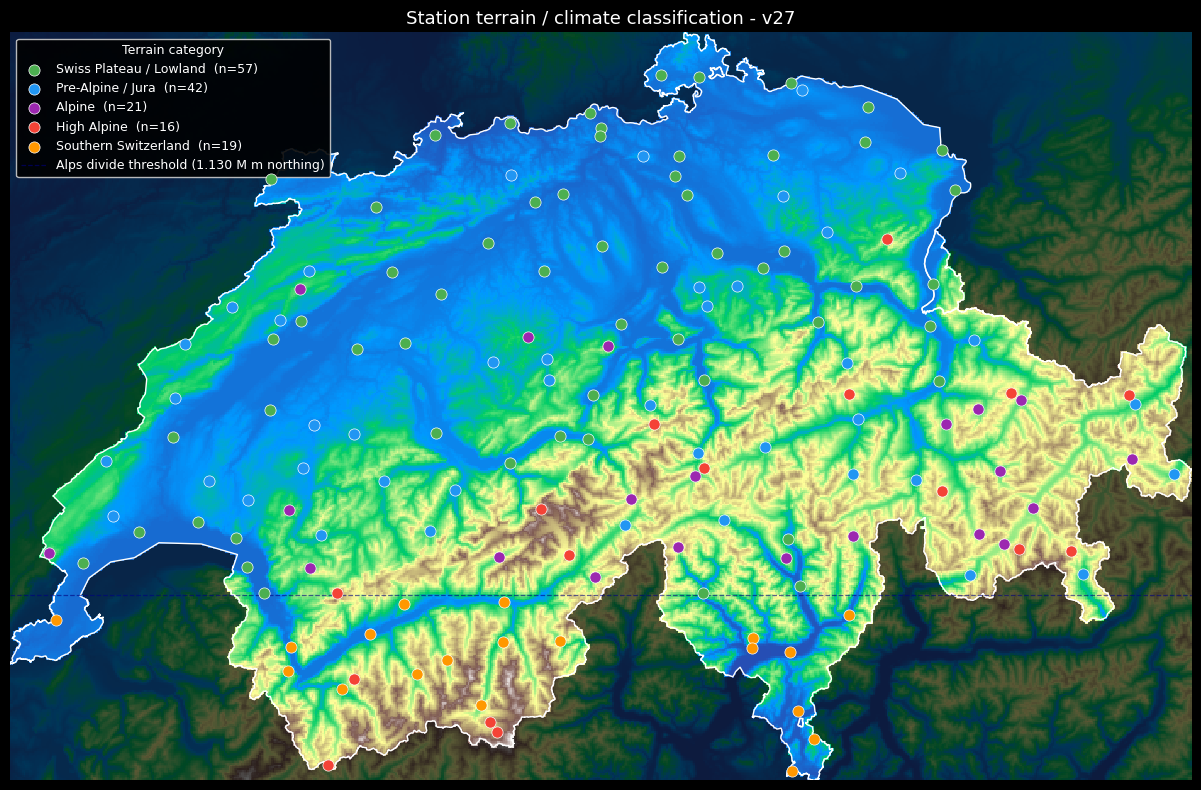

In [13]:
fig, ax = plt.subplots(figsize=(13, 8))
draw_dem(ax, dem_bg, dem_fg, switzerland)

for cat in TERRAIN_CATEGORIES:
    sub = df_mr0[df_mr0['terrain'] == cat].dropna(subset=['e_lv95', 'n_lv95'])
    ax.scatter(
        sub['e_lv95'], sub['n_lv95'],
        color=TERRAIN_COLORS[cat], s=65,
        edgecolors='white', linewidths=0.5, zorder=8,
        label=f'{cat}  (n={len(sub)})',
    )

ax.axhline(ALPS_DIVIDE_NORTHING, color='navy', linewidth=0.9, linestyle='--', alpha=0.6,
           label=f'Alps divide threshold ({ALPS_DIVIDE_NORTHING/1e6:.3f} M m northing)')

ax.legend(fontsize=9, framealpha=0.9, loc='upper left',
          title='Terrain category', title_fontsize=9)
ax.set_title(f'Station terrain / climate classification - {RUN_NAME}', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'map_terrain_categories.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 2 — Per-variable MAE maps: mr0.00 (all stations visible)

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(28, 5))
fig.suptitle(f'MAE by station - {RUN_NAME} mr0.00 (all stations visible)', fontsize=14, y=1.01)

for ax, (var, col, unit, cmap, (lo, hi)) in zip(axes, VARIABLES):
    draw_dem(ax, dem_bg, dem_fg, switzerland)
    sc = scatter_metric(ax, df_mr0, col, cmap=cmap, vmin=lo, vmax=hi, size=55)
    plt.colorbar(sc, ax=ax, fraction=0.035, pad=0.02, label=unit)
    ax.set_title(var, fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'map_mae_mr0.00.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 3 — Per-variable MAE maps: mr0.50 (50% stations masked)

In [ ]:
if df_mr5 is not None:
    fig, axes = plt.subplots(1, 5, figsize=(28, 5))
    fig.suptitle(f'MAE by station - {RUN_NAME} mr0.50 (gap-filling + forecasting)', fontsize=14, y=1.01)

    for ax, (var, col, unit, cmap, (lo, hi)) in zip(axes, VARIABLES):
        draw_dem(ax, dem_bg, dem_fg, switzerland)
        sc = scatter_metric(ax, df_mr5, col, cmap=cmap, vmin=lo, vmax=hi, size=55)
        plt.colorbar(sc, ax=ax, fraction=0.035, pad=0.02, label=unit)
        ax.set_title(var, fontsize=11)

    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'map_mae_mr0.50.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(f"No mr0.50 dump for run '{RUN_NAME}' - skipping.")

---
## 4 — Overall RMSE map (both mask ratios, side by side)

In [ ]:
if df_mr5 is not None:
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    for ax, (df, title) in zip(axes, [
        (df_mr0, f'Overall RMSE - {RUN_NAME} mr0.00 (no masking)'),
        (df_mr5, f'Overall RMSE - {RUN_NAME} mr0.50 (50% masked)'),
    ]):
        draw_dem(ax, dem_bg, dem_fg, switzerland)
        sc = scatter_metric(ax, df, 'overall_rmse_norm', cmap='plasma_r', vmin=0.3, vmax=1.0, size=60)
        plt.colorbar(sc, ax=ax, fraction=0.035, pad=0.02, label='RMSE (norm.)')
        ax.set_title(title, fontsize=11)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'map_overall_rmse.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    fig, ax = plt.subplots(figsize=(9, 6))
    draw_dem(ax, dem_bg, dem_fg, switzerland)
    sc = scatter_metric(ax, df_mr0, 'overall_rmse_norm', cmap='plasma_r', vmin=0.3, vmax=1.0, size=60)
    plt.colorbar(sc, ax=ax, fraction=0.035, pad=0.02, label='RMSE (norm.)')
    ax.set_title(f'Overall RMSE - {RUN_NAME} mr0.00 (no mr0.50 dump for this run)', fontsize=11)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'map_overall_rmse.png'), dpi=150, bbox_inches='tight')
    plt.show()

---
## 5 — Masking penalty map: Delta MAE = mr0.50 - mr0.00

**Red** = stations that are harder to predict when masked from the encoder.
**White / green** = stations the model reconstructs well even without seeing their
own input.

In [ ]:
if df_mr5 is not None:
    diff = df_mr0[['station_idx', 'e_lv95', 'n_lv95', 'station_height', 'terrain']].copy()
    for var, col, unit, _, _ in VARIABLES:
        diff[f'd_{col}'] = df_mr5[col].values - df_mr0[col].values
    diff['d_overall_mae'] = df_mr5['overall_mae_norm'].values - df_mr0['overall_mae_norm'].values

    fig, axes = plt.subplots(1, 5, figsize=(28, 5))
    fig.suptitle(f'{RUN_NAME} masking penalty DMAE = mr0.50 - mr0.00  (red = harder when masked)',
                 fontsize=13, y=1.01)
    for ax, (var, col, unit, _, _) in zip(axes, VARIABLES):
        draw_dem(ax, dem_bg, dem_fg, switzerland)
        sc = scatter_metric(ax, diff, f'd_{col}', cmap='RdBu_r', vmin=-0.5, vmax=0.5, size=55)
        plt.colorbar(sc, ax=ax, fraction=0.035, pad=0.02, label=unit)
        ax.set_title(var, fontsize=11)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'map_masking_penalty.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(f"No mr0.50 dump for run '{RUN_NAME}' - skipping.")
    diff = None

---
## 6 — Terrain grouped statistics

Mean +/- std of per-station MAE for each terrain category and variable. Stations
with < `MIN_SAMPLES` valid observations for a variable are excluded from that
cell.

In [ ]:
def terrain_grouped_stats(df):
    records = []
    for cat in TERRAIN_CATEGORIES:
        sub = df[df['terrain'] == cat]
        row = {'terrain': cat, 'n_stations': len(sub)}
        for var, col, unit, _, _ in VARIABLES:
            n_col = f'{var}_n_samples'
            if n_col in sub.columns:
                valid = sub[sub[n_col] >= MIN_SAMPLES][col].dropna()
            else:
                valid = sub[col].dropna()
            row[f'{var}_mae']  = round(valid.mean(), 3) if len(valid) else float('nan')
            row[f'{var}_std']  = round(valid.std(),  3) if len(valid) else float('nan')
            row[f'{var}_n']    = len(valid)
        records.append(row)
    return pd.DataFrame(records).set_index('terrain')

stats_mr0 = terrain_grouped_stats(df_mr0)
mean_cols = [f'{var}_mae' for var, *_ in VARIABLES]

print(f'Mean MAE by terrain - {RUN_NAME} mr0.00 (no masking) [physical units]')
display(stats_mr0[['n_stations'] + mean_cols])

if df_mr5 is not None:
    stats_mr5 = terrain_grouped_stats(df_mr5)
    print(f'\nMean MAE by terrain - {RUN_NAME} mr0.50 (50% masked) [physical units]')
    display(stats_mr5[['n_stations'] + mean_cols])

---
## 7 — Masking penalty by terrain category

Which terrain types suffer most when stations are hidden from the encoder? A large
positive bar = the model relies on nearby stations to interpolate that region, so
hiding them hurts. Near-zero / negative = the model generalises well from temporal
context alone.

In [ ]:
if df_mr5 is not None and diff is not None:
    diff['terrain'] = df_mr0['terrain'].values
    VAR_COLORS = ['#E53935', '#8E24AA', '#1E88E5', '#43A047', '#FB8C00']

    fig, ax = plt.subplots(figsize=(12, 5))
    x = np.arange(len(TERRAIN_CATEGORIES))
    w = 0.14

    for i, (var, col, unit, _, _) in enumerate(VARIABLES):
        d_col = f'd_{col}'
        means, stds = [], []
        for cat in TERRAIN_CATEGORIES:
            vals = diff[diff['terrain'] == cat][d_col].dropna()
            means.append(vals.mean())
            stds.append(vals.std())
        offset = (i - 2) * w
        ax.bar(x + offset, means, width=w*0.9, color=VAR_COLORS[i], alpha=0.85, label=var)
        ax.errorbar(x + offset, means, yerr=stds,
                    fmt='none', color='black', capsize=2.5, linewidth=0.8)

    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xticks(x)
    ax.set_xticklabels([TERRAIN_SHORT[c] for c in TERRAIN_CATEGORIES], fontsize=10)
    ax.set_ylabel('DMAE = mr0.50 - mr0.00 (physical units)', fontsize=9)
    ax.set_title(f'{RUN_NAME} masking penalty by terrain  (positive = harder when masked | '
                 'negative = helped by masking)', fontsize=10)
    ax.legend(fontsize=9, loc='upper right', ncol=5)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'terrain_masking_penalty.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(f"No mr0.50 dump for run '{RUN_NAME}' - skipping.")

---
## 8 — Temperature MAE: dot fill = error, outline = terrain category

Combine the geographic MAE pattern with terrain classification in a single map.

In [ ]:
_panels = [(df_mr0, f'Temperature MAE - {RUN_NAME} mr0.00')]
if df_mr5 is not None:
    _panels.append((df_mr5, f'Temperature MAE - {RUN_NAME} mr0.50'))

fig, axes = plt.subplots(1, len(_panels), figsize=(10 * len(_panels), 7), squeeze=False)
axes = axes[0]

for ax, (df, title) in zip(axes, _panels):
    draw_dem(ax, dem_bg, dem_fg, switzerland)
    sc_last = None
    for cat in TERRAIN_CATEGORIES:
        sub = df[df['terrain'] == cat].dropna(subset=['e_lv95', 'n_lv95', 'temperature_mae'])
        lo, hi = VARIABLES[0][4]
        sc_last = ax.scatter(
            sub['e_lv95'], sub['n_lv95'],
            c=sub['temperature_mae'], cmap='plasma_r', vmin=lo, vmax=hi,
            s=70, edgecolors=TERRAIN_COLORS[cat], linewidths=1.8, zorder=8,
        )
    if sc_last is not None:
        plt.colorbar(sc_last, ax=ax, fraction=0.035, pad=0.02, label='deg C')
    ax.set_title(title, fontsize=11)

handles = [
    mpatches.Patch(edgecolor=TERRAIN_COLORS[c], facecolor='#DDDDDD',
                   linewidth=1.8, label=c)
    for c in TERRAIN_CATEGORIES
]
axes[0].legend(handles=handles, fontsize=8, title='Terrain (outline)', loc='upper left')
plt.suptitle('Temperature MAE - dot fill = error magnitude  |  outline colour = terrain category',
             fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'map_temperature_mae_terrain.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 9 — Station altitude vs MAE scatter (coloured by terrain)

Circles = mr0.00  |  Triangles = mr0.50 (if available)

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(26, 4))
fig.suptitle(f'{RUN_NAME} station altitude vs MAE by terrain  '
             '(circle = mr0.00' + ('  |  triangle = mr0.50)' if df_mr5 is not None else ')'),
             fontsize=12, y=1.02)

for ax, (var, col, unit, _, _) in zip(axes, VARIABLES):
    for cat in TERRAIN_CATEGORIES:
        c = TERRAIN_COLORS[cat]
        s0 = df_mr0[df_mr0['terrain'] == cat].dropna(subset=['station_height', col])
        ax.scatter(s0['station_height'], s0[col], color=c, alpha=0.8,
                   s=25, marker='o', label=cat)
        if df_mr5 is not None:
            s5 = df_mr5[df_mr5['terrain'] == cat].dropna(subset=['station_height', col])
            ax.scatter(s5['station_height'], s5[col], color=c, alpha=0.35,
                       s=25, marker='^')
    ax.set_xlabel('Altitude (m)', fontsize=8)
    ax.set_ylabel(f'MAE ({unit})', fontsize=8)
    ax.set_title(var, fontsize=10)
    ax.set_ylim(bottom=0)
    ax.grid(alpha=0.3)

color_handles = [mpatches.Patch(color=TERRAIN_COLORS[c], label=c) for c in TERRAIN_CATEGORIES]
shape_handles = [plt.scatter([], [], marker='o', color='grey', alpha=0.8, s=25, label='mr0.00')]
if df_mr5 is not None:
    shape_handles.append(plt.scatter([], [], marker='^', color='grey', alpha=0.35, s=25, label='mr0.50'))
axes[0].legend(handles=color_handles + shape_handles, fontsize=7, loc='upper left',
               title='Terrain / mask', title_fontsize=7, ncol=1)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'scatter_altitude_mae_terrain.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 10 — Masked stations example

Shows which stations the encoder sees vs. which it must reconstruct for one test
window. Uses the dump's **real** `masked_idx` tensor (v27 schema records the exact
encoder mask per window) rather than re-simulating it.

In [ ]:
WINDOW_IDX = 42    # change to inspect other windows

if pred_mr5 is not None and pred_mr5.get("masked_idx") is not None and pred_mr5["masked_idx"].shape[1] > 0:
    y_mask = pred_mr5['masks']            # (M, K, N, V)
    N_ = y_mask.shape[2]

    has_data   = y_mask[WINDOW_IDX, 0, :, :5].any(dim=-1).numpy()
    masked_set = set(pred_mr5['masked_idx'][WINDOW_IDX].tolist())
    n_masked   = len(masked_set)

    e_all = df_mr5['e_lv95'].values
    n_all = df_mr5['n_lv95'].values

    status = []
    for i in range(len(df_mr5)):
        if not has_data[i]:    status.append('no_data')
        elif i in masked_set:  status.append('masked')
        else:                  status.append('visible')
    status = np.array(status)

    fig, ax = plt.subplots(figsize=(11, 8))
    draw_dem(ax, dem_bg, dem_fg, switzerland)

    for grp, color, marker, sz, lab, zo in [
        ('visible', '#2196F3', 'o', 60, 'Visible (context)',       8),
        ('masked',  '#F44336', 'X', 75, 'Masked (model predicts)', 10),
        ('no_data', '#AAAAAA', 'o', 30, 'No sensor data',          6),
    ]:
        sel = status == grp
        ax.scatter(e_all[sel], n_all[sel], color=color, marker=marker, s=sz,
                   edgecolors='white', linewidths=0.5, label=lab, zorder=zo)

    ax.legend(fontsize=9, framealpha=0.85, loc='upper left')
    ax.set_title(f'{RUN_NAME} encoder masking (real masked_idx) - window #{WINDOW_IDX}   '
                 f'({n_masked}/{N_} stations hidden)', fontsize=11)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'map_masked_stations_example.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Visible: {(status=="visible").sum()}  '
          f'Masked: {(status=="masked").sum()}  '
          f'No data: {(status=="no_data").sum()}')
else:
    print(f"No mr0.50 dump (with masked_idx) for run '{RUN_NAME}' - skipping.")

---
## 11 — Best / worst stations by temperature MAE

In [ ]:
TOP_N = 10
base_cols = ['nat_abbr', 'station_idx', 'station_height', 'terrain',
             'temperature_mae', 'temperature_rmse', 'overall_mae_norm']

_dfs = [('mr0.00', df_mr0)]
if df_mr5 is not None:
    _dfs.append(('mr0.50', df_mr5))

for label, df in _dfs:
    sub = df.dropna(subset=['temperature_mae']).sort_values('temperature_mae')
    print(f'\n-- {label} Top-{TOP_N} BEST temperature MAE')
    display(sub[base_cols].head(TOP_N).reset_index(drop=True))
    print(f'\n-- {label} Top-{TOP_N} WORST temperature MAE')
    display(sub[base_cols].tail(TOP_N).reset_index(drop=True))

---
## 12 — Humidity RMSE spatial pattern

Humidity can show an anomalously high spike at nowcast (delta=0). Map it to see if
the issue clusters geographically.

In [ ]:
_panels = [(df_mr0, f'Humidity RMSE - {RUN_NAME} mr0.00')]
if df_mr5 is not None:
    _panels.append((df_mr5, f'Humidity RMSE - {RUN_NAME} mr0.50'))

fig, axes = plt.subplots(1, len(_panels), figsize=(9 * len(_panels), 6), squeeze=False)
axes = axes[0]
for ax, (df, title) in zip(axes, _panels):
    draw_dem(ax, dem_bg, dem_fg, switzerland)
    sc = scatter_metric(ax, df, 'humidity_rmse', cmap='RdPu', vmin=0, vmax=30, size=60)
    plt.colorbar(sc, ax=ax, fraction=0.035, pad=0.02, label='%')
    ax.set_title(title, fontsize=11)
plt.suptitle('Humidity RMSE (%)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'map_humidity_rmse.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 13 — Raw prediction vs target: time series for best and worst station

Picks the station with the best and worst temperature MAE (mr0.50 if available,
else mr0.00), 30-min lead time.

In [ ]:
VAR_IDX   = 0   # 0=temperature  1=pressure  2=humidity  3=wind_u  4=wind_v
DELTA_IDX = 1   # K index: 0=0 min  1=30 min  2=60 min ...
VAR_NAME  = 'temperature'

_pred_ts, _df_ts, _tag_ts = (pred_mr5, df_mr5, 'mr0.50') if pred_mr5 is not None else (pred_mr0, df_mr0, 'mr0.00')

preds_t   = _pred_ts['preds']    # (M, K, N, V)
targets_t = _pred_ts['targets']  # (M, K, N, V)
masks_t   = _pred_ts['masks']    # (M, K, N, V)

sub = _df_ts.dropna(subset=['temperature_mae'])
best_idx  = int(sub.nsmallest(1, 'temperature_mae')['station_idx'].values[0])
worst_idx = int(sub.nlargest(1,  'temperature_mae')['station_idx'].values[0])

for idx, tag in [(best_idx, 'Best'), (worst_idx, 'Worst')]:
    row = sub[sub['station_idx'] == idx].iloc[0]
    abbr = row.get('nat_abbr', f'idx={idx}')
    print(f'{tag}: {abbr}  |  {row["station_height"]:.0f} m  |  {row["terrain"]}  '
          f'|  temperature_mae={row["temperature_mae"]:.3f} deg C')

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

for ax, (idx, title_tag) in zip(axes, [(best_idx, 'Best'), (worst_idx, 'Worst')]):
    row  = sub[sub['station_idx'] == idx].iloc[0]
    abbr = row.get('nat_abbr', f'idx={idx}')
    cat  = row.get('terrain', '?')

    pred_vals   = preds_t[:, DELTA_IDX, idx, VAR_IDX].numpy()
    target_vals = targets_t[:, DELTA_IDX, idx, VAR_IDX].numpy()
    valid       = masks_t[:, DELTA_IDX, idx, VAR_IDX].numpy().astype(bool)

    x = np.arange(len(pred_vals))
    ax.plot(x[valid], target_vals[valid], color='#CCCCCC', lw=1.4, alpha=0.95, label='target')
    ax.plot(x[valid], pred_vals[valid],   color='#FF4444', lw=1.1, alpha=0.9,
            linestyle='--', label='pred')
    mae = np.abs(pred_vals[valid] - target_vals[valid]).mean()
    ax.set_title(f'{title_tag}: {abbr}  ({cat}, {row["station_height"]:.0f} m)  '
                 f'temperature @30 min  MAE={mae:.3f} (norm.)', fontsize=10)
    ax.set_ylabel('Norm. value')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

axes[-1].set_xlabel('Test window index')
plt.suptitle(f'{VAR_NAME} predictions - {RUN_NAME} {_tag_ts} - {len(x)} windows', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'timeseries_best_worst.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 14 — Persistence baseline comparison

Per-station RMSE for the model vs a persistence forecast (last observed value held
constant). Lead times **k = 1 ... 12** only (30 min - 6 h); k = 0 is excluded
because persistence is trivially perfect there.

**Skill score** = 1 - model_RMSE / persistence_RMSE
-> **positive (blue)** = model beats persistence
-> **negative (red)** = persistence beats model

In [ ]:
VAR_NAMES_5 = ['temperature', 'pressure', 'humidity', 'wind_u', 'wind_v']

def _per_station_rmse_from_tensors(pred_dict, label=''):
    """
    Compute per-station overall RMSE from a predictions.pt dict.
    Uses lead times k=1..K-1 (excludes nowcast k=0).

    Returns a DataFrame with columns: station_idx, overall_rmse_norm,
    {var}_rmse_norm for each of the 5 target variables.
    """
    preds   = pred_dict['preds']                 # (M, K, N, 5)
    targets = pred_dict['targets'][:, :, :, :5]  # (M, K, N, 5)
    masks   = pred_dict['masks'  ][:, :, :, :5]  # (M, K, N, 5)

    persist = targets[:, 0:1, :, :]              # (M, 1, N, 5)

    model_sq   = (preds   [:, 1:, :, :] - targets[:, 1:, :, :]) ** 2
    persist_sq = (persist.expand_as(preds[:, 1:, :, :]) - targets[:, 1:, :, :]) ** 2
    mask_fwd   = masks[:, 1:, :, :].bool()

    N_ = preds.shape[2]
    rows_m, rows_p = [], []
    for n in range(N_):
        rm = {'station_idx': n}
        rp = {'station_idx': n}
        sq_sum_m = sq_sum_p = 0.0
        n_vars = 0
        for v, var in enumerate(VAR_NAMES_5):
            m_nv = mask_fwd[:, :, n, v]
            cnt  = int(m_nv.sum().item())
            if cnt > 0:
                ms = float(model_sq  [:, :, n, v][m_nv].mean().item())
                ps = float(persist_sq[:, :, n, v][m_nv].mean().item())
                rm[f'{var}_rmse_norm'] = ms ** 0.5
                rp[f'{var}_rmse_norm'] = ps ** 0.5
                sq_sum_m += ms
                sq_sum_p += ps
                n_vars   += 1
            else:
                rm[f'{var}_rmse_norm'] = float('nan')
                rp[f'{var}_rmse_norm'] = float('nan')
        rm['overall_rmse_norm'] = (sq_sum_m / n_vars) ** 0.5 if n_vars else float('nan')
        rp['overall_rmse_norm'] = (sq_sum_p / n_vars) ** 0.5 if n_vars else float('nan')
        rows_m.append(rm)
        rows_p.append(rp)

    df_m = pd.DataFrame(rows_m).merge(coords, on='station_idx', how='left')
    df_p = pd.DataFrame(rows_p).merge(coords, on='station_idx', how='left')
    df_m['terrain'] = classify_terrain(df_m)
    df_p['terrain'] = classify_terrain(df_p)
    if label:
        print(f'{label} - overall RMSE (norm, k>0)  '
              f'model median={df_m["overall_rmse_norm"].median():.3f}  '
              f'persist median={df_p["overall_rmse_norm"].median():.3f}')
    return df_m, df_p


_runs14 = [('mr0.00', pred_mr0)]
if pred_mr5 is not None:
    _runs14.append(('mr0.50', pred_mr5))

_results14 = {}
for tag, pred in _runs14:
    df_m, df_p = _per_station_rmse_from_tensors(pred, tag)
    skill_col = df_m[['station_idx', 'e_lv95', 'n_lv95', 'nat_abbr', 'terrain']].copy()
    skill_col['skill'] = 1.0 - df_m['overall_rmse_norm'].values / df_p['overall_rmse_norm'].values
    _results14[tag] = (df_m, df_p, skill_col)

_all_rmse = pd.concat(
    [df_m['overall_rmse_norm'] for df_m, _, _ in _results14.values()]
    + [df_p['overall_rmse_norm'] for _, df_p, _ in _results14.values()]
).dropna()
RMSE_VMIN = float(_all_rmse.quantile(0.02))
RMSE_VMAX = float(_all_rmse.quantile(0.98))
print(f'Shared RMSE color scale: [{RMSE_VMIN:.3f}, {RMSE_VMAX:.3f}]')

fig, axes = plt.subplots(len(_results14), 3, figsize=(27, 6 * len(_results14)), squeeze=False)
fig.suptitle(
    f'{RUN_NAME} per-station RMSE - model vs persistence (lead times 30 min - 6 h)\n'
    'Skill = 1 - model/persistence  (blue = model better  |  red = persistence better)',
    fontsize=13, y=1.01
)

for row_idx, (tag, (df_m, df_p, df_sk)) in enumerate(_results14.items()):
    mr_tag = f'{tag} ({"all visible" if tag == "mr0.00" else "50% masked"})'

    ax = axes[row_idx, 0]
    draw_dem(ax, dem_bg, dem_fg, switzerland)
    sc = scatter_metric(ax, df_m, 'overall_rmse_norm', cmap='plasma_r',
                        vmin=RMSE_VMIN, vmax=RMSE_VMAX, size=60)
    plt.colorbar(sc, ax=ax, fraction=0.035, pad=0.02, label='RMSE (norm.)')
    ax.set_title(f'Model - {mr_tag}', fontsize=11)

    ax = axes[row_idx, 1]
    draw_dem(ax, dem_bg, dem_fg, switzerland)
    sc = scatter_metric(ax, df_p, 'overall_rmse_norm', cmap='plasma_r',
                        vmin=RMSE_VMIN, vmax=RMSE_VMAX, size=60)
    plt.colorbar(sc, ax=ax, fraction=0.035, pad=0.02, label='RMSE (norm.)')
    ax.set_title(f'Persistence - {mr_tag}', fontsize=11)

    ax = axes[row_idx, 2]
    draw_dem(ax, dem_bg, dem_fg, switzerland)
    sc = scatter_metric(ax, df_sk, 'skill', cmap='RdBu', vmin=-0.3, vmax=0.3, size=60)
    plt.colorbar(sc, ax=ax, fraction=0.035, pad=0.02, label='Skill score')
    ax.set_title(f'Skill score - {mr_tag}', fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'map_persistence_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\nMedian per-station skill score (1 - model/persistence):')
for tag, (_, _, df_sk) in _results14.items():
    print(f'  {tag:8s} {df_sk["skill"].median():+.3f}   '
          f'({(df_sk["skill"] > 0).sum()}/{len(df_sk)} stations beat persistence)')